# Task 2: Predictive Modeling

In this task, I will develop multiple predictive models to predict `SalePrice` based on the 
clean data created in Task-1. The predictive Models are going to be evaluated using K-Fold 
cross-validation and compared across RMSE, MAE, and R² metrics.

In [1]:
#Important libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import shap

#Suppress warnings
import warnings
warnings.filterwarnings('ignore')

## Models
- **Linear Regression** — interpretable baseline model
- **Random Forest** — robust ensemble, can also handle non-linearity
- **XGBoost** — gradient boosting, typically strongest on tabular data

## Target Variable
`SalePrice_log` — log-transformed sale price to address skewness identified in `Task-1`.

In [2]:
#Load the dataset
df = pd.read_csv('housing_data_900.csv')

In [3]:
# --- Reproduce cleaning steps from Task 1 to keep this notebook self-contained ---

#Drop high-missing columns
df = df.drop(columns=['Pool QC', 'Misc Feature', 'Alley', 'Fence'])

In [4]:
#Fill categorical absences with 'None'
cat_none = ['Mas Vnr Type', 'Fireplace Qu', 'Garage Type', 'Garage Finish',
            'Garage Qual', 'Garage Cond', 'Bsmt Qual', 'Bsmt Cond',
            'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2']

df[cat_none] = df[cat_none].fillna('None')

In [5]:
#Fill numerical absences with 0
num_zero = ['Garage Yr Blt', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2',
            'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath']

df[num_zero] = df[num_zero].fillna(0)

In [6]:
#Lot Frontage — median imputation
df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].median())

In [7]:
#Electrical — mode imputation
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [8]:
#Remove outliers
df = df[df['Gr Liv Area'] <= 4000]

In [9]:
#Log-transform target variable
df['SalePrice_log'] = np.log1p(df['SalePrice'])

In [10]:
#Check final shape after cleaning
df.shape

(897, 79)

## Data Preparation
The cleaning pipeline from **Task-1** is reproduced here to ensure consistency:
- High-missing columns dropped
- Categorical and numerical missing values imputed using domain-appropriate strategies
- Extreme outliers in `Gr Liv Area` removed
- Target variable log-transformed to address skewness

## Feature Engineering & Encoding

We separate features into numerical and categorical types.
- **Numerical features** are used directly
- **Categorical features** are encoded using **Label Encoding**, which is appropriate 
  for tree-based models (Random Forest, XGBoost) and keeps dimensionality manageable 
  given the large number of categorical columns (~40)
- For **Linear Regression**, I am aware that Label Encoding assumes ordinality, 
  but since we have many categorical features, if I use **One-Hot Encoding**, the dimensionality would be too high. Hence, I would use Label Encoding for all the models.

In [11]:
#Drop the non-predictive identifier columns and the original target variable, keeping only the log-transformed target for modeling
cols_to_drop = ['Order', 'PID', 'SalePrice', 'SalePrice_log']
X = df.drop(columns = cols_to_drop)
y = df['SalePrice_log']

In [12]:
#Separate categorical and numerical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

In [13]:
#Print feature counts
print(f"Categorical features: {len(cat_cols)}")
print(f"Numerical features: {len(num_cols)}")
print(f"Total features: {X.shape[1]}")

Categorical features: 39
Numerical features: 36
Total features: 75


In [14]:
#Apply Label Encoding to categorical columns
label_encoder = LabelEncoder()

#looping through each categorical column and apply label encoding
for col in cat_cols:
    X[col] = label_encoder.fit_transform(X[col].astype(str))

## Train/Test Split & Cross-Validation Setup

The data is going to be split into **80% training** and **20% testing**.  
Additionally, **5-Fold Cross-Validation** is going to be used during training to ensure evaluation 
is robust and not dependent on a single random split.

All the models are going to be evaluated using:
- **RMSE** — penalizes large errors more heavily
- **MAE** — average absolute error, intuitive for stakeholders
- **R²** — proportion of variance explained by the model

In [15]:
#Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [16]:
#K-Fold setup
k_fold = KFold(n_splits=5, shuffle=True, random_state=42)

In [17]:
#Helper function to evaluate a model
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    #Return rounded metrics
    return {'RMSE': round(rmse, 4), 'MAE': round(mae, 4), 'R²': round(r2, 4)}

In [18]:
#Print dataset sizes after the train/test split
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 717
Test set size: 180


## First Model : Linear Regression

Linear Regression is our **baseline model**. It assumes a linear relationship 
between the features and the target variable, and is highly interpretable.  
Although this model will not likely identify any complex relationships between the data (the non-linear patterns), it is a benchmark for performance that should be met by any model.

In [19]:
#Train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [20]:
#Cross-validation score (R²)
lr_cv_scores = cross_val_score(lr, X_train, y_train, cv=k_fold, scoring='r2')

print(f"Linear Regression CV R² scores: {lr_cv_scores.round(4)}")
print(f"Mean CV R²: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std():.4f})")

Linear Regression CV R² scores: [0.8598 0.7596 0.8909 0.9216 0.9345]
Mean CV R²: 0.8733 (+/- 0.0624)


In [21]:
#Evaluate on test set 
lr_results = evaluate_model(lr, X_test, y_test)

print(f"\nTest Set Performance:")
print(f"RMSE: {lr_results['RMSE']}")
print(f"MAE:  {lr_results['MAE']}")
print(f"R²:   {lr_results['R²']}")


Test Set Performance:
RMSE: 0.1053
MAE:  0.079
R²:   0.9322


### Linear Regression Results

- The model achieves an R² of **0.9322** on the test set, meaning it explains 
  ~93% of the variance in log-transformed sale prices — this is a strong baseline.
- RMSE of **0.1053** and MAE of **0.0790** are in log-scale, meaning predictions 
  are on average within ~8% of the actual sale price.
- These are surprisingly strong results for a linear model, likely because the 
  log transformation made the target more linear and the feature relationships 
  more regular.
- Random Forest and XGBoost should push these numbers further, particularly by 
  capturing non-linear interactions between features.

## Second Model: Random Forest

Random Forest is an ensemble method that builds multiple decision trees and averages 
their predictions. It handles non-linear relationships and feature interactions 
naturally, is robust to outliers, and provides built-in feature importance scores.  
It serves as a strong middle ground between the interpretable baseline and the 
more complex gradient boosting model.

In [22]:
#Train Random Forest
rf = RandomForestRegressor(n_estimators = 100, random_state = 42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [23]:
#Cross-validation score (R²)
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv = k_fold, scoring='r2')
print(f"Random Forest CV R² scores: {rf_cv_scores.round(4)}")
print(f"Mean CV R²: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")

Random Forest CV R² scores: [0.8645 0.7097 0.9082 0.8797 0.9105]
Mean CV R²: 0.8545 (+/- 0.0745)


In [24]:
#Evaluate on test set
rf_results = evaluate_model(rf, X_test, y_test)
print(f"\nTest Set Performance:")
print(f"RMSE: {rf_results['RMSE']}")
print(f"MAE:  {rf_results['MAE']}")
print(f"R²:   {rf_results['R²']}")


Test Set Performance:
RMSE: 0.1155
MAE:  0.0834
R²:   0.9184


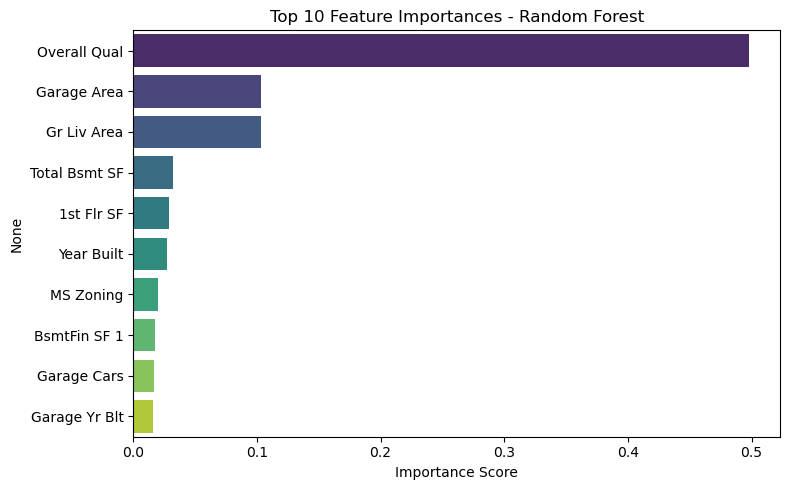

In [25]:
#Feature Importance Plot
feat_importance = pd.Series(rf.feature_importances_, index=X.columns)
top_features = feat_importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

### Random Forest Results

- Random Forest achieves an R² of **0.9184**, RMSE of **0.1155**, and MAE of **0.0834** 
  on the test set — slightly below Linear Regression's performance.
- This is not uncommon with default hyperparameters on a relatively small dataset (900 rows). 
  Random Forest with `n_estimators=100` and no tuning may be overfitting the training data 
  slightly, hurting generalization.

- The feature importance plot reveals that **`Overall Qual` dominates overwhelmingly** 
  with an importance score of ~0.50 — nearly 5× higher than the next features. 
  `Garage Area` and `Gr Liv Area` follow, with `Total Bsmt SF`, `1st Flr SF`, and 
  `Year Built` rounding out the top 6.
- This is fully consistent with the correlation analysis in Task-1, validating our 
  earlier findings from a modeling perspective.
- XGBoost with hyperparameter tuning is expected to outperform both models by 
  reducing bias and variance more effectively.

## Third Model: XGBoost

Extreme Gradient Boosting, or XGBoost, is a strong ensemble method that builds trees 
sequentially, with each tree correcting the errors of the previous one. It is widely 
regarded as one of the best-performing algorithms on structured/tabular data.

Unlike Random Forest which builds trees independently, XGBoost's sequential nature 
allows it to focus on hard-to-predict samples, typically resulting in lower bias.
We will make use of the **RandomizedSearchCV** for hyperparameter tuning to find the best  
configuration rather than relying on defaults.

In [26]:
#Define parameter grid for RandomizedSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]}

In [27]:
#Base XGBoost model
xgb_base = xgb.XGBRegressor(random_state=42, verbosity=0)

In [28]:
#RandomizedSearchCV
xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions = param_grid,
    n_iter = 30,
    scoring='r2',
    cv = k_fold,
    random_state = 42,
    n_jobs = -1)

In [29]:
#Fit the model
xgb_search.fit(X_train, y_train)

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=Non...
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='r2')

In [30]:
#Print best parameters and CV score
print(f"Best Parameters: {xgb_search.best_params_}")
print(f"Best CV R²: {xgb_search.best_score_:.4f}")

Best Parameters: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.7}
Best CV R²: 0.8939


In [31]:
#Retrieve the best trained model from RandomizedSearchCV
xgb_best = xgb_search.best_estimator_

In [32]:
#Cross-validation score
xgb_cv_scores = cross_val_score(xgb_best, X_train, y_train, cv=k_fold, scoring='r2')
print(f"XGBoost CV R² scores: {xgb_cv_scores.round(4)}")
print(f"Mean CV R²: {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std():.4f})")

XGBoost CV R² scores: [0.9216 0.7736 0.9317 0.9172 0.931 ]
Mean CV R²: 0.8950 (+/- 0.0610)


In [33]:
#Evaluate on test set
xgb_results = evaluate_model(xgb_best, X_test, y_test)
print(f"\nTest Set Performance:")
print(f"RMSE: {xgb_results['RMSE']}")
print(f"MAE:  {xgb_results['MAE']}")
print(f"R²:   {xgb_results['R²']}")


Test Set Performance:
RMSE: 0.0938
MAE:  0.0708
R²:   0.9462


### XGBoost Results:

- XGBoost achieves the best performance across all metrics — R² of **0.9462**, 
  RMSE of **0.0938**, and MAE of **0.0708** on the test set.

- Compared to Linear Regression (R² 0.9322) and Random Forest (R² 0.9184), 
  XGBoost's sequential boosting approach combined with hyperparameter tuning 
  delivers a measurable improvement in predictive accuracy.
- An RMSE of **0.0938** in log-scale translates to predictions that are on average 
  within ~9% of the actual sale price — strong performance for a real estate pricing model.
- These results confirm XGBoost as the best model and the one we will use for 
  SHAP analysis in the next section.

## Model Comparison

All three models are going to be compared side-by-side across RMSE, MAE, and R² to provide 
a clear picture of relative performance and justify the selection of XGBoost 
as the final model.

In [34]:
#Build comparison dataframe for all models
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost (Tuned)'],
    'RMSE': [lr_results['RMSE'], rf_results['RMSE'], xgb_results['RMSE']],
    'MAE':  [lr_results['MAE'],  rf_results['MAE'],  xgb_results['MAE']],
    'R²':   [lr_results['R²'],   rf_results['R²'],   xgb_results['R²']]
})

#Print comparison results
print(results.to_string(index=False))

            Model   RMSE    MAE     R²
Linear Regression 0.1053 0.0790 0.9322
    Random Forest 0.1155 0.0834 0.9184
  XGBoost (Tuned) 0.0938 0.0708 0.9462


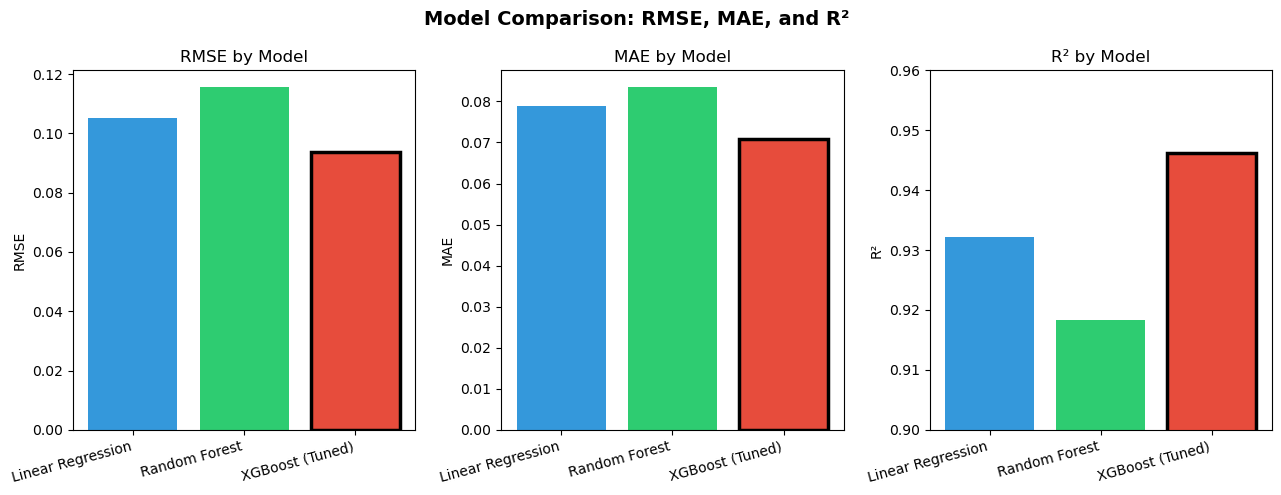

In [35]:
#One Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

metrics = ['RMSE', 'MAE', 'R²']
colors = ['#3498db', '#2ecc71', '#e74c3c']

#Bar plots for each metric
for i, metric in enumerate(metrics):
    axes[i].bar(results['Model'], results[metric], color=colors)
    axes[i].set_title(f'{metric} by Model')
    axes[i].set_ylabel(metric)
    axes[i].set_xticks(range(len(results['Model'])))
    axes[i].set_xticklabels(results['Model'], rotation=15, ha='right')
    
    if metric == 'R²':
        axes[i].set_ylim(0.90, 0.96)  # Add this line
    best_idx = results[metric].idxmin() if metric != 'R²' else results[metric].idxmax()
    axes[i].patches[best_idx].set_edgecolor('black')
    axes[i].patches[best_idx].set_linewidth(2.5)

plt.suptitle('Model Comparison: RMSE, MAE, and R²', fontsize=14, fontweight='bold')
plt.tight_layout()


plt.show()

### Comparison Summary:

- **XGBoost (Tuned)** outperforms both models across all three metrics, achieving 
  the lowest RMSE (0.0938), lowest MAE (0.0708), and highest R² (0.9462).
- **Linear Regression** performs surprisingly well as a baseline (R² 0.9322), 
  benefiting from the log transformation of the target variable applied in Task-1.
- **Random Forest** underperforms with default parameters on this dataset size, 
  highlighting the importance of hyperparameter tuning — which is why we applied 
  RandomizedSearchCV to XGBoost.
- XGBoost is selected as the **final model** and will be further analyzed using 
  SHAP in the next section.

## SHAP Analysis

SHAP (SHapley Additive Explanations) is a state-of-the-art model explainability 
technique grounded in game theory. It assigns each feature a contribution score 
for every individual prediction, answering the question:  
*"How much did each feature push this prediction higher or lower?"*

Unlike standard feature importance (which gives a single global score per feature), 
SHAP provides both:
- **Global insights** — which features matter most overall
- **Local insights** — why the model made a specific prediction for a specific house

This is particularly valuable for communicating model behavior to non-technical 
stakeholders such as real estate agents or property investors.

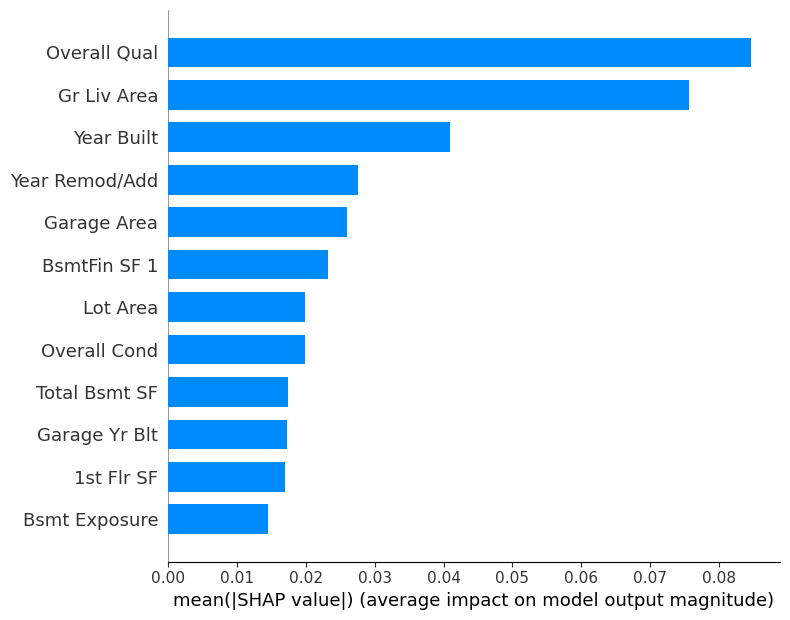

In [ ]:
#Compute SHAP values for XGBoost
explainer = shap.Explainer(xgb_best.predict, X_test_array)
shap_values = explainer(X_test_array)

#Summary plot — global feature importance with directionality
shap.summary_plot(shap_values, X_test, 
                  feature_names=X_test.columns.tolist(),
                  plot_type="bar", 
                  max_display=12)

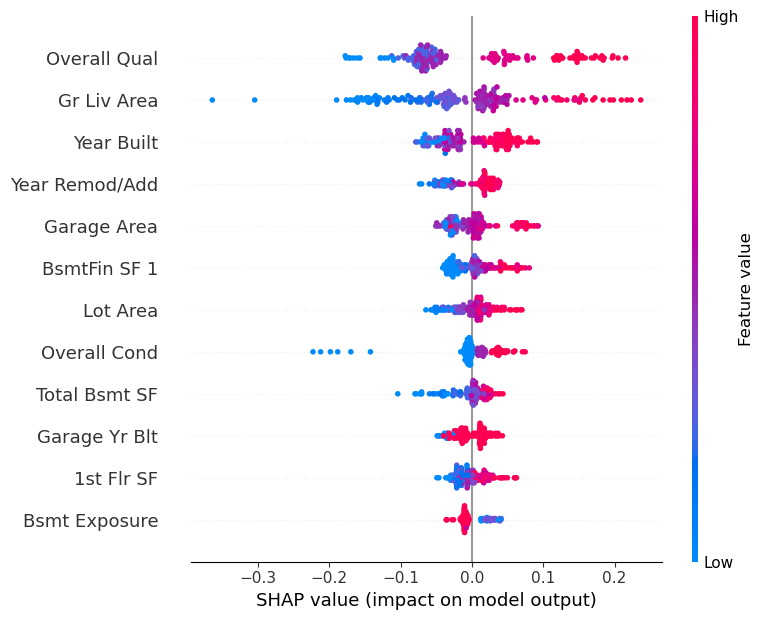

In [ ]:
#Beeswarm plot — shows direction and magnitude of each feature's impact
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns.tolist(), max_display = 12)

### SHAP Analysis Insights:

**Bar Plot (Global Importance):**
- `Overall Qual` and `Gr Liv Area` are the two dominant predictors by a significant 
  margin, followed by `Year Built`, `Year Remod/Add`, and `Garage Area`.
- Notably, SHAP gives `Gr Liv Area` much more credit than Random Forest's built-in 
  importance did — SHAP is generally considered a more reliable importance measure 
  as it accounts for feature interactions.

**Beeswarm Plot (Direction & Magnitude):**
- **`Overall Qual`**: High values (red) push predictions strongly to the right 
  (higher price), while low values (blue) pull predictions left — the clearest 
  and most consistent signal in the dataset.
- **`Gr Liv Area`**: Shows the widest horizontal spread of any feature, meaning 
  living area creates the largest variance in predictions. A few extreme red dots 
  far right confirm that very large homes command significantly higher prices.
- **`Year Built` & `Year Remod/Add`**: Predominantly red dots on the positive side, 
  confirming that newer and recently renovated homes consistently command higher prices.
- **`Overall Cond`**: Interestingly shows a few blue outliers with strong negative 
  SHAP values (-0.2), indicating that poor condition homes are heavily penalized 
  by the model.
- **`BsmtFin SF 1`**: Blue dots on the left confirm that absence of finished basement 
  space pulls predicted prices down noticeably.

**Key Takeaway:** SHAP confirms that the model's predictions are driven by intuitive, 
domain-consistent factors — quality, size, age, and condition. This gives us confidence 
that the model has learned genuine market patterns rather than noise, and makes its 
predictions explainable to non-technical stakeholders such as real estate agents 
or property investors.

## Conclusion

This notebook developed and compared three machine learning models to predict 
housing sale prices using the cleaned dataset from Task-1.

### Model Performance Summary

| Model | RMSE | MAE | R² |
|---|---|---|---|
| Linear Regression | 0.1053 | 0.0790 | 0.9322 |
| Random Forest | 0.1155 | 0.0834 | 0.9184 |
| XGBoost (Tuned) | **0.0938** | **0.0708** | **0.9462** |

**XGBoost** emerged as the best performing model across all metrics, achieving an 
R² of **0.9462** — meaning it explains ~94.6% of the variance in housing sale prices.

### Key Findings
- **Overall Quality** is the single strongest predictor of sale price, consistent 
  across correlation analysis (Task 1), Random Forest importance, and SHAP analysis.
- **Living area, basement size, and garage features** are the next most impactful 
  factors, confirming that size-related features are primary price drivers.
- **Newer and recently renovated homes** consistently command higher prices, as 
  confirmed by both the decade trend analysis (Task 1) and SHAP values.
- **Log-transforming the target variable** was a critical preprocessing step that 
  improved all models by normalizing the skewed distribution of sale prices.

### Why XGBoost Won
Linear Regression performed surprisingly well as a baseline thanks to the log 
transformation, while Random Forest underperformed with default parameters — 
highlighting the importance of hyperparameter tuning. XGBoost with 
RandomizedSearchCV found the optimal configuration that minimized both bias 
and variance effectively.

## Potential Improvements

While the current model achieves strong performance, several enhancements could 
further improve accuracy and robustness:

1. **Advanced Feature Engineering** — Create interaction features such as 
   `Quality × Living Area` or `Age Since Remodel`, which may capture non-linear 
   relationships not currently represented in the raw features.

2. **One-Hot Encoding for Linear Regression** — Applying proper `One-Hot Encoding` to categorical 
   features for the linear model would remove the ordinality assumption introduced 
   by Label Encoding, potentially improving its performance.

3. **Stacking / Ensemble** — Combining predictions from all three models using a 
   meta-learner (stacking) could squeeze out additional performance beyond what 
   any single model achieves.

4. **Neighborhood Encoding** — Given the strong neighborhood effect identified in 
   Task 1, replacing Label Encoding with Target Encoding for `Neighborhood` 
   (encoding by median sale price per neighborhood) could significantly improve 
   model accuracy.

5. **Expanded Hyperparameter Tuning** — Increasing `n_iter` in RandomizedSearchCV 
   or switching to Bayesian Optimization (e.g., `optuna`) would explore a wider 
   parameter space more efficiently.

6. **Larger Dataset** — The current dataset contains 900 rows, which is relatively 
   small for complex ensemble models. Training on the full Ames Housing dataset 
   (~2,900 rows) would likely improve generalization significantly.

### Scalability Considerations
The existing pipeline was designed with scalability in mind. Label Encoding and 
vectorized pandas operations ensure efficient memory usage on larger datasets. 
For production-scale data, the pipeline could be wrapped in `sklearn.Pipeline` 
for streamlined preprocessing, and XGBoost's built-in support for distributed 
computing (via Dask or Spark) would allow training on datasets significantly 
larger than the existing 900-row sample.